# Interactions and polynomial features

1. **polynomial features**
2. **interaction features**

These transformations allow a linear model to represent more flexible relationships

## Why do we need them?

A basic linear regression model has the form:

\begin{align*}
y=\beta_0 + \beta_1x_1 + \beta_2 x_2 +\cdots
\end{align*}

- each feature enters the model **linearly**
- the effect of one feature does **not** depend on another feature unless we explicitly add such a term

To make linear models more flexible, we can expand the original feature space.

--- 
## Main ideas

### Polynomial features
Polynomial features and powers of a variable, such as:
- $x$
- $x^2$
- $x^3$

This allows a linear model to fit **curved relationships**

\begin{align*}
y = \beta_0 +\beta_1x + \beta_2x^2
\end{align*}

This is still a **linear model in the coefficients** $\beta$, even though it is nonlinear in $x$

---
### Interaction features
Interaction features multiply variables together, such as
$x_1x_2$

This allows the effect of one variable to depend on the value of another.
\begin{align*}
y = \beta_0 +\beta_1x_1 + \beta_2x_2 + \beta_3x_1x_2
\end{align*}

If $\beta_3\neq 0$, the effect of $x_1$ changes depending on $x_2$

---
## Scikit-learn tool

The main tool is 

```python

from sklearn.preprocessing import PolynomialFeatures
```
It can generate:

- polynomial terms
- interaction terms
- both together


## 1. Imports

In [47]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

## 2. A simple one-feature example

Suppose the true relationship is curved.
A plain liner regression may fit poorly, while polynomail features can help.

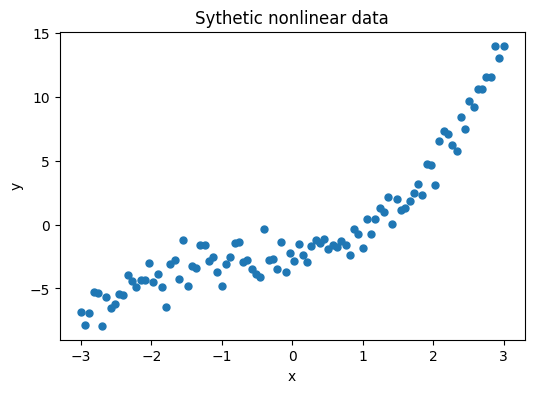

In [48]:
rng = np.random.RandomState(0)

X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 0.3 * X[:, 0]**3 + 0.5 * X[:, 0]**2 + X[:, 0] - 2 + rng.normal(scale=1.0, size=100)
plt.figure(figsize=(6, 4))
plt.scatter(X, y,s=25)
plt.title("Sythetic nonlinear data")
plt.xlabel("x" )
plt.ylabel("y")
plt.show()

The data are generated from a quadratic relationship, so a straight line is unlikely to catpure the pattern well.

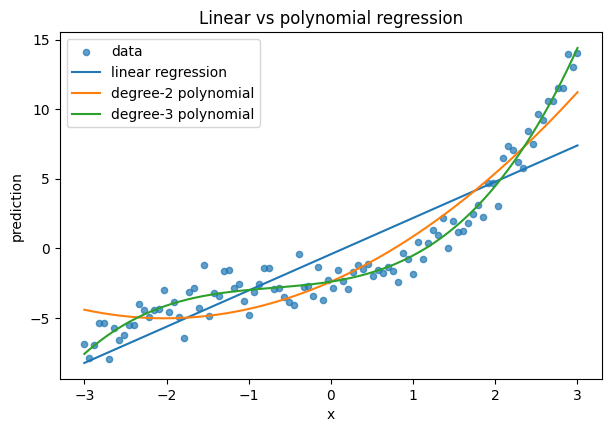

In [49]:
line = np.linspace(-3, 3, 500).reshape(-1, 1)

lm = LinearRegression().fit(X, y)
y_pred_lm = lm.predict(line)

#poly2_model = make_pipeline(
#    PolynomialFeatures(degree=2, include_bias=False),
#    LinearRegression()
#)

poly2_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
y_pred_poly2 = poly2_model.fit(X, y).predict(line)


poly3_model = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression()
)
poly3_model.fit(X, y)
y_pred_poly3 = poly3_model.predict(line)

plt.figure(figsize=(7, 4.5))
plt.scatter(X[:, 0], y, s=20, alpha=0.7, label="data")
plt.plot(line[:, 0], y_pred_lm, label="linear regression")
plt.plot(line[:, 0], y_pred_poly2, label="degree-2 polynomial")
plt.plot(line[:, 0], y_pred_poly3, label="degree-3 polynomial")
plt.xlabel("x")
plt.ylabel("prediction")
plt.title("Linear vs polynomial regression")
plt.legend()
plt.show()



## 3. What does `Polynomial Features` actually create?

In [50]:
X_small = np.array([[0], [1], [2], [3]])

poly = PolynomialFeatures(degree=3, include_bias=False)
X_small_poly = poly.fit_transform(X_small)

print("original X:")
print(X_small)

print("\ntransformed X:")
print(X_small_poly)

print("\nFeature names:")
print(poly.get_feature_names_out())

original X:
[[0]
 [1]
 [2]
 [3]]

transformed X:
[[ 0.  0.  0.]
 [ 1.  1.  1.]
 [ 2.  4.  8.]
 [ 3.  9. 27.]]

Feature names:
['x0' 'x0^2' 'x0^3']


For one original feature `x`, degree 3 generates:
- `x`
- `x^2`
- `x^3`

So the linear model is fitted on the expanded features, not on the original `x` alone

## 4. Two-feature example: interactions

Now suppose the outcome depends on the interaction between two variables.


In [51]:
rng = np.random.RandomState(0)

n = 200
x1 = rng.uniform(-2, 2, size=n)
x2 = rng.uniform(-2, 2, size=n)

X = np.column_stack([x1, x2])

y = 1 + 2 * x1 - 1.5 * x2 + 3 * x1 * x2 + rng.normal(scale=1, size=n)

df = pd.DataFrame(X, columns=["x1", "x2"])
df["y"] = y
df.head()

,x1,x2,y
0,0.195254,-0.752816,2.772535
1,0.860757,0.785374,3.411930
2,0.411054,-0.488993,1.818888
3,0.179533,-1.281585,3.668928
4,-0.305381,-1.901285,3.856188


If we fit a model with only the main effects `x1` and `x2`, it cannot directly represent the term $x_1x_2$.


In [52]:
main_effects_model = LinearRegression().fit(X, y)
pred_main = main_effects_model.predict(X)


interaction_features = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_inter = interaction_features.fit_transform(X)
pred_inter = LinearRegression().fit(X_inter, y).predict(X_inter)

print("R^2 without interaction:", round(r2_score(y, pred_main), 3))
print("R^2 with interaction:", round(r2_score(y, pred_inter), 3))
print("\nInteraction feature names:")
print(interaction_features.get_feature_names_out(["x1", "x2"]))



R^2 without interaction: 0.347
R^2 with interaction: 0.963

Interaction feature names:
['x1' 'x2' 'x1 x2']


### Important note about `interaction_only=True`

If `interaction_only=True`, the transformer creates only:
- `x1`
- `x2`
- `x1x2`

and does **not** include squared terms such as $x_1^2$ or $x_2^2$.
This is useful when you specifically want to model ineractions without adding full polynomial curvate. 

## 5. Compare the transformed matrices

Compare three versions:
1. original features
2. full polynomial features (degree=2)
3. interaction-only features




In [53]:
X_demo = np.array([[1, 2],
                   [3, 4]])

poly_full = PolynomialFeatures(degree=2, include_bias=False)
X_full = poly_full.fit_transform(X_demo)

poly_inter = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_inter = poly_inter.fit_transform(X_demo)

print("Original X:")
print(X_demo)

print("\nFull degree-2 polynomial features:")
print(X_full)
print(poly_full.get_feature_names_out(["x1", "x2"]))

print("\nInteraction-only degree-2 features:")
print(X_inter)
print(poly_inter.get_feature_names_out(["x1", "x2"]))


Original X:
[[1 2]
 [3 4]]

Full degree-2 polynomial features:
[[ 1.  2.  1.  2.  4.]
 [ 3.  4.  9. 12. 16.]]
['x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']

Interaction-only degree-2 features:
[[ 1.  2.  2.]
 [ 3.  4. 12.]]
['x1' 'x2' 'x1 x2']


For two variables `x1` and `x2`, **full degree-2 polynomial expansion** gives:

- `x1`
- `x2`
- `x1^2`
- `x1 x2`
- `x2^2`

while **interaction-only** gives:

- `x1`
- `x2`
- `x1 x2`

## 6. Why this matters conceptually

Feature engineering changes the **representation** of the input.

A plain linear model is limited to straight-line effects in the original variables.

But after feature expansion, the same linear model can represent:

- curvature
- interactions
- more complex surfaces

So the model is still linear in the coefficients, but **nonlinear in the original input variables**.

## 7. Key takeaways

- `PolynomialFeatures` expands the feature space
- Degree 2 adds squares and pairwise products
- Degree 3 adds cubes and higher-order combinations
- `interaction_only=True` keeps interaction terms but excludes powers like $x^2$
- Linear regression on transformed features can model nonlinear relationships
- These transformations are examples of **feature engineering**

In short:

We are not changing the learning algorithm;

We are changing the **representations of the data**

